In [1]:
import importlib
import pandas as pd
import sys
sys.path.append(r'C:/Users/cleme/OneDrive/Documents/Travail/Dauphine/M2/Electronic Market/project/fx_market_making/src/')
import utils.order_book.order_book_impl as book_utils
import utils.order_book.utils as utils
import utils.order_book.graphic_utils as graph_utils

In [2]:
importlib.reload(book_utils)
importlib.reload(utils)
importlib.reload(graph_utils)
Order_book = book_utils.Order_book()
Order_book._generate_n_random_order(100)

Generating order book: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 100/100 [00:00<00:00, 472.30it/s]


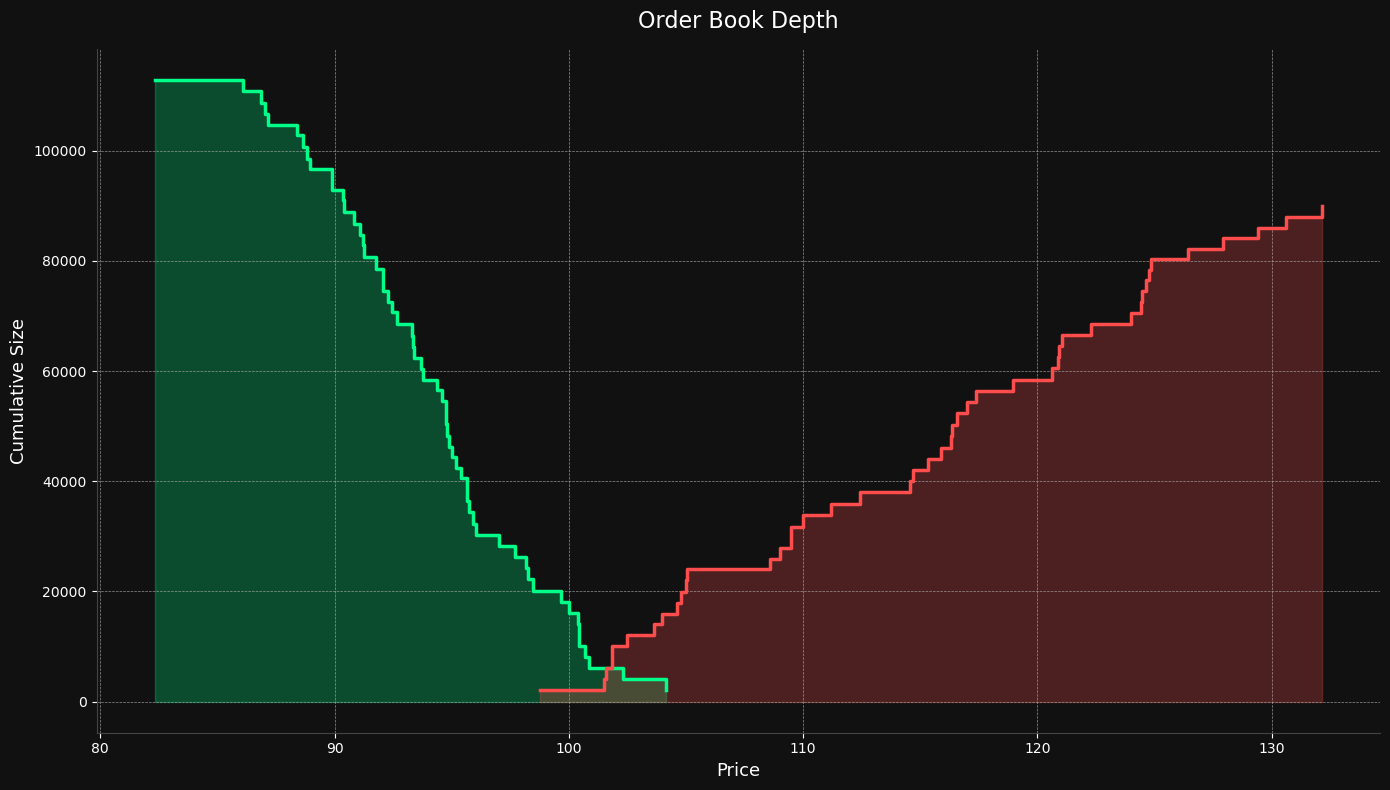

In [3]:
importlib.reload(book_utils)
graph_utils.plot_order_book(Order_book)

In [4]:
Order_book._df_bid_book

,Id,Price,Size,Type,Origin,Time
1776176776526_5264,1776176776526_5264,100.014000,2052,limit_order,market_maker,2026-04-14 16:26:16.526
1776176776530_6323,1776176776530_6323,98.469167,2112,limit_order,market_maker,2026-04-14 16:26:16.530
1776176776536_6543,1776176776536_6543,100.425013,1829,limit_order,market_maker,2026-04-14 16:26:16.536
1776176776538_9900,1776176776538_9900,98.156497,2060,limit_order,market_maker,2026-04-14 16:26:16.538
1776176776546_0081,1776176776546_0081,95.633160,1959,limit_order,market_maker,2026-04-14 16:26:16.546
1776176776548_6573,1776176776548_6573,100.438632,2086,limit_order,market_maker,2026-04-14 16:26:16.548
1776176776550_2831,1776176776550_2831,92.074946,1984,limit_order,market_maker,2026-04-14 16:26:16.550
1776176776553_0244,1776176776553_0244,99.665028,1923,limit_order,market_maker,2026-04-14 16:26:16.553
1776176776555_4860,1776176776555_4860,98.249643,2093,limit_order,market_maker,2026-04-14 16:26:16.555
1776176776558_6098,1776176776558_6098,104.169445,2094,limit_order,market_maker,2026-04-14 16:26:16.558


In [26]:
importlib.reload(book_utils)
importlib.reload(graph_utils)

ob = book_utils.Order_book()
ob._generate_n_random_order(40)

print(f"MM book: {len(ob._df_order_book)} orders")
print(f"  Bids: {(ob._df_order_book["Direction"]=="buy").sum()}")
print(f"  Asks: {(ob._df_order_book["Direction"]=="sell").sum()}")
print(f"  Best bid: {ob._df_order_book[ob._df_order_book["Direction"]=="buy"]["Price"].max():.4f}")
print(f"  Best ask: {ob._df_order_book[ob._df_order_book["Direction"]=="sell"]["Price"].min():.4f}")
graph_utils.plot_order_book(ob)

## Simulation

The market maker order book is now seeded. Key properties:
- All orders have `origin = "market_maker"`
- Bids and asks never cross (bid always < best ask)
- Prices generated via truncated normal distribution anchored on last price

Next steps:
1. **Generate client orders** with `generate_random_orders(n, origin="client")` — returns a list, does not touch the book
2. **Submit the batch** with `add_orders_batch(orders)` — adds to book then triggers clearing
3. **Inspect matches** in `ob._df_matches` — client vs MM orders, price-time priority, partial fills supported
4. **Cancel orders** to clean up the book after clearing

In [27]:
client_orders = ob.generate_random_orders(10, origin="client")
ob.add_orders_batch(client_orders)

In [ ]:
ob._df_ask_book.sort_values("Price")

,Id,Price,Size,Type,Origin,Time
1776176907433_7768,1776176907433_7768,122.410887,1936,limit_order,market_maker,2026-04-14 16:28:27.433
1776176907441_6578,1776176907441_6578,123.670297,2038,limit_order,market_maker,2026-04-14 16:28:27.441
1776176907444_4284,1776176907444_4284,118.612424,1998,limit_order,market_maker,2026-04-14 16:28:27.444
1776176907448_9669,1776176907448_9669,115.236404,2124,limit_order,market_maker,2026-04-14 16:28:27.448
1776176907454_1715,1776176907454_1715,112.516452,1891,limit_order,market_maker,2026-04-14 16:28:27.454
1776176907457_0887,1776176907457_0887,112.524758,1912,limit_order,market_maker,2026-04-14 16:28:27.457
1776176907474_9815,1776176907474_9815,110.718738,2078,limit_order,market_maker,2026-04-14 16:28:27.474
1776176907489_6052,1776176907489_6052,115.372784,1790,limit_order,market_maker,2026-04-14 16:28:27.489
1776176907498_6234,1776176907498_6234,122.871122,2127,limit_order,market_maker,2026-04-14 16:28:27.498
1776176907500_7691,1776176907500_7691,115.823900,2133,limit_order,market_maker,2026-04-14 16:28:27.500


In [28]:
len(ob._df_ask_book)

24

In [29]:
client_orders = ob.generate_random_orders(10, origin="client")
ob.add_orders_batch(client_orders)

print(f"Matches: {len(ob._df_matches)}")
ob._df_matches[["Direction", "Price", "MatchedSize", "ClientOrderId", "MmOrderId"]]

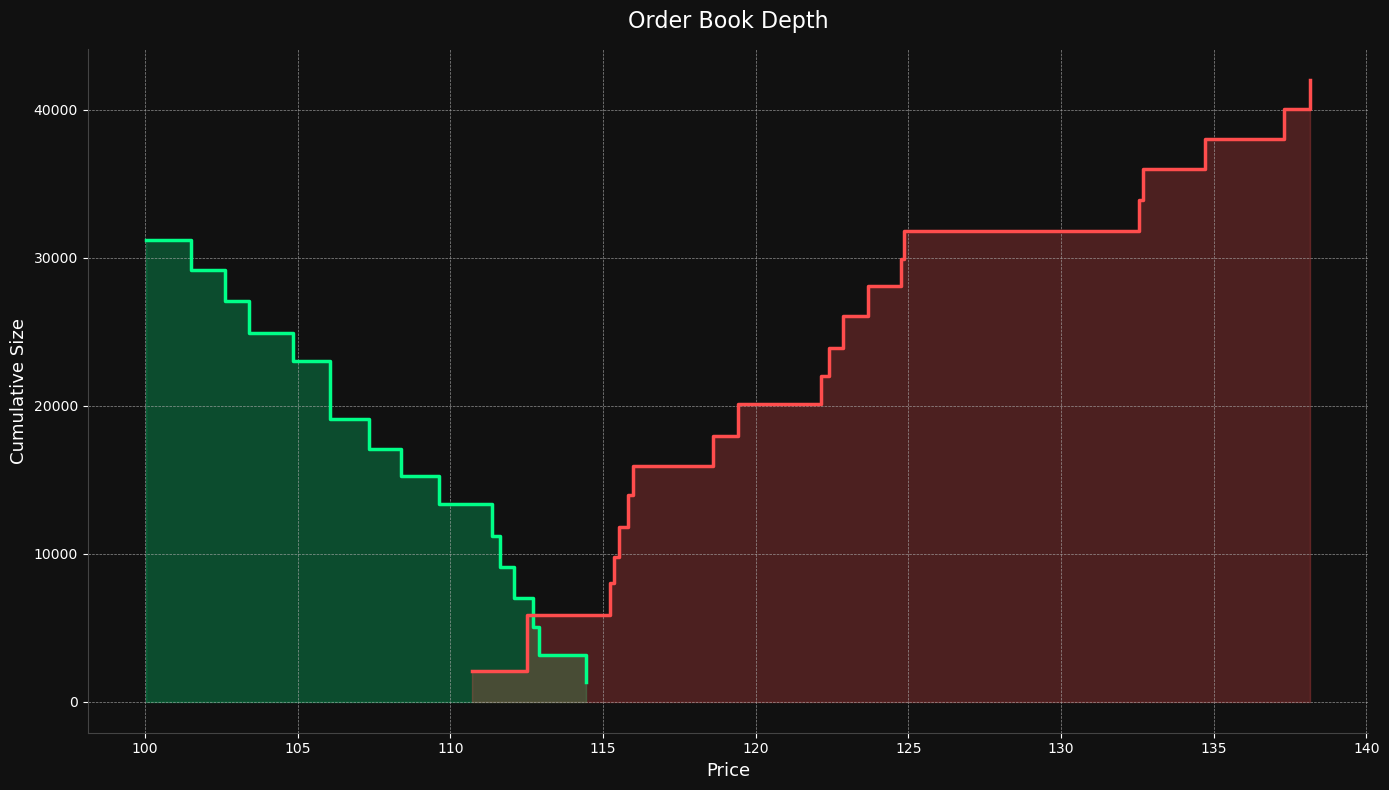

In [30]:
graph_utils.plot_order_book(ob)

In [9]:
if not ob._df_matches.empty:
    by_dir = ob._df_matches.groupby("Direction").agg(
        Matches=("MatchedSize", "count"),
        Volume=("MatchedSize", "sum"),
        AvgPrice=("Price", "mean"),
    )
    print(f"Total matched volume : {ob._df_matches['MatchedSize'].sum():,.0f}")
    print(f"Remaining open orders: {len(ob._df_order_book)}")
    print()
    print(by_dir)
else:
    print("No matches â€” client prices did not cross MM quotes (try re-running)")

No matches â€” client prices did not cross MM quotes (try re-running)


In [10]:
# cancel specific orders by ID
some_ids = ob._df_order_book.index[:3].tolist()
print(f"Before cancel_orders: {len(ob._df_order_book)} orders")
ob.cancel_orders(some_ids)
print(f"After cancel_orders({len(some_ids)} ids): {len(ob._df_order_book)} orders")

# cancel all remaining MM orders
mm_count = (ob._df_order_book["Origin"] == "market_maker").sum()
ob.cancel_all_mm_orders()
print(f"After cancel_all_mm_orders ({mm_count} removed): {len(ob._df_order_book)} orders left")
print("Remaining orders (should be client-only):")
ob._df_order_book[["Direction", "Price", "Size", "Origin"]].head(10)

Before cancel_orders: 51 orders
After cancel_orders(3 ids): 48 orders
After cancel_all_mm_orders (38 removed): 10 orders left
Remaining orders (should be client-only):


,Direction,Price,Size,Origin
1776176777313_8827,buy,82.822320,1931,client
1776176777320_3420,sell,205.452048,1838,client
1776176777325_2013,sell,191.190907,1988,client
1776176777331_1959,sell,194.831332,1937,client
1776176777337_7099,buy,79.579397,2077,client
1776176777339_8212,sell,213.836182,1910,client
1776176777341_5823,buy,78.036374,2057,client
1776176777345_7238,buy,79.791477,1925,client
1776176777348_0841,buy,81.384671,2101,client
1776176777350_1393,buy,73.208717,2035,client
